## 11-06-2026 STATISTICS
First statistics class. Statistics is the science of collecting, organizing, analyzing and interpreting data to make decisions under uncertainty. Numbers alone are hard to act on, statistics turns them into understanding.

Topics covered today:
1. Types of statistics (descriptive vs inferential)
2. Basic terms
3. Descriptive statistics with an example
4. Types of data (categorical, numerical)
5. Levels of measurement (nominal, ordinal, interval, ratio)
6. Measures of central tendency (mode, median, mean)
7. Measures of dispersion (range, variance, standard deviation)
8. Symmetric and asymmetric distributions, skewness
9. Probability density function
10. Distributions: normal, Bernoulli, binomial, uniform, Poisson
11. Standard normal distribution, empirical rule, z-score

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
np.random.seed(7)

### Types of Statistics
Statistics splits into two branches:

- **Descriptive statistics** summarizes the data you already have (averages, spread, charts). It does not go beyond the data.
- **Inferential statistics** uses a sample to draw conclusions about a larger population you did not fully measure (confidence intervals, hypothesis tests).

Difference with an example: if I measure the heights of 50 students and report their average, that is descriptive. If I use those 50 to estimate the average height of all 5000 students in the college, that is inferential.

In [2]:
# descriptive: summarize the data in hand
heights = np.array([160, 165, 170, 172, 168, 175, 158, 169, 171, 167])
print("descriptive  -> mean of these 10:", heights.mean())

# inferential: use the sample to estimate the whole population mean (a range)
se = heights.std(ddof=1) / np.sqrt(len(heights))
print("inferential  -> population mean likely near", round(heights.mean(),1),
      "give or take", round(1.96*se,1))

descriptive  -> mean of these 10: 167.5
inferential  -> population mean likely near 167.5 give or take 3.3


### Basic Terms
- **Population:** the entire group you want to study (all 5000 students).
- **Sample:** the subset you actually measure (the 50 you surveyed).
- **Variable:** a characteristic that varies across observations (height, gender).
- **Datum:** a single recorded value. **Data:** the plural, the whole collection.
- **Experiment:** a process where you control or change something and record the outcome.
- **Parameter:** a number describing the population (mu, sigma). Usually unknown.
- **Statistic:** a number computed from the sample (x-bar, s). Estimates the parameter.

In [3]:
# parameter (population) vs statistic (sample)
population = np.arange(1, 5001)        # imagine all 5000 students' IDs as a stand-in
sample = np.random.choice(population, size=50, replace=False)
print("population size (N):", population.size)
print("sample size (n):", sample.size)
print("a statistic, the sample mean:", round(sample.mean(), 2))

population size (N): 5000
sample size (n): 50
a statistic, the sample mean: 2898.14


### Descriptive Statistics with an Example
Descriptive statistics describes a dataset using its centre, its spread, and its shape. The fastest tool in pandas is `describe()`, which reports all the key summaries at once. Example: exam scores of 10 students.

In [4]:
scores = pd.Series([55, 60, 64, 66, 70, 72, 78, 85, 88, 95])
scores.describe()
# count = how many, mean = average, std = spread,
# min/25%/50%/75%/max = the five-number summary

count    10.000000
mean     73.300000
std      12.953335
min      55.000000
25%      64.500000
50%      71.000000
75%      83.250000
max      95.000000
dtype: float64

### Types of Data
Every variable is either categorical or numerical, and the type decides which analysis is valid.

**1. Categorical data** are labels, not amounts. Examples: gender (male/female), city (Tampa/Miami), payment method. You count them and find the most common, but you cannot average them.

**2. Numerical data** are numbers you can do math on. Examples: age, height, salary, number of children. These split into **discrete** (countable, like number of children) and **continuous** (measured, like height).

In [5]:
# categorical: count categories, you cannot take a mean
gender = pd.Series(['M', 'F', 'F', 'M', 'F', 'M', 'F'])
print(gender.value_counts())          # counts per category
print("most common (mode):", gender.mode()[0])

F    4
M    3
Name: count, dtype: int64
most common (mode): F


In [6]:
# numerical: math like mean and sum makes sense
age = pd.Series([21, 22, 20, 23, 21, 24, 22])
print("mean age:", age.mean(), " total:", age.sum())

mean age: 21.857142857142858  total: 153


### Levels of Measurement
A finer classification that ranks how much information a variable carries.

**1. Qualitative (categorical)**
- **a. Nominal:** categories with no order (eye color, blood type, city).
- **b. Ordinal:** categories with a clear order but unequal gaps (small/medium/large, ratings 1 to 5).

**2. Quantitative (numerical)**
- **a. Interval:** equal gaps, but no true zero, so ratios do not work (temperature in C, calendar years).
- **b. Ratio:** equal gaps and a true zero, so ratios make sense (height, weight, income).

Decision rule: order? no = nominal. yes = is the gap equal? no = ordinal. yes = true zero? no = interval, yes = ratio.

### Measures of Central Tendency
A single number for the centre of the data.

- **Mode:** the most frequent value. Works for categorical data too.
- **Median:** the middle value when sorted. Robust to outliers.
- **Mean:** the average (sum / count). Uses every value but is sensitive to outliers.

In [7]:
scores = np.array([55, 60, 64, 66, 70, 72, 78, 85, 88, 95])
print("mode  :", stats.mode(scores, keepdims=False).mode)   # no repeats here, returns smallest
print("median:", np.median(scores))
print("mean  :", scores.mean())

mode  : 55
median: 71.0
mean  : 73.3


In [8]:
# why the median is robust: one outlier barely moves it but wrecks the mean
bad = np.array([55, 60, 64, 66, 70, 72, 78, 85, 88, 195])
print("mean with outlier  :", bad.mean())     # pulled up a lot
print("median with outlier:", np.median(bad)) # barely changes

mean with outlier  : 83.3
median with outlier: 71.0


### Measures of Dispersion
How spread out the data is around the centre.

- **Range:** max minus min. Simple but only uses two values.
- **Variance:** average squared distance from the mean (sample divides by n-1).
- **Standard deviation:** square root of variance, back in the original units, the typical distance from the mean.

In [9]:
print("range   :", scores.max() - scores.min())
print("variance:", round(scores.var(ddof=1), 2))     # ddof=1 for a sample
print("std dev :", round(scores.std(ddof=1), 2))

range   : 40
variance: 167.79
std dev : 12.95


### Symmetric and Asymmetric Distributions, Skewness
A distribution is **symmetric** if both sides of the centre mirror each other (the normal bell curve), and **asymmetric** if one tail is longer. **Skewness** measures that asymmetry.

- **Skewed left (negative):** long tail on the left, mean < median.
- **Symmetric (zero skew):** mean = median = mode.
- **Skewed right (positive):** long tail on the right, mean > median (e.g. income).

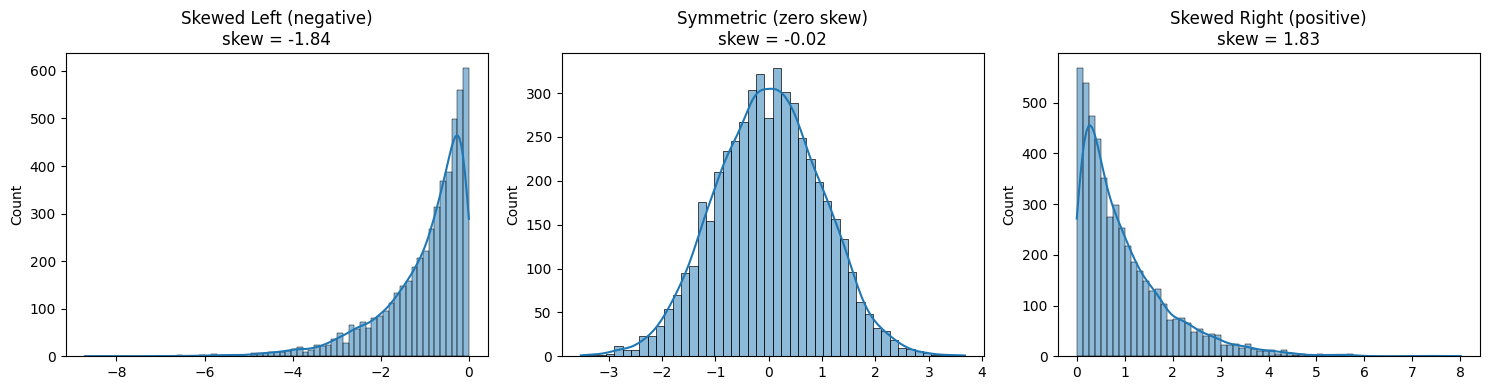

In [10]:
# generate three shapes and plot them side by side
left  = -np.random.exponential(1, 5000)        # long tail to the left
symm  =  np.random.normal(0, 1, 5000)           # symmetric
right =  np.random.exponential(1, 5000)         # long tail to the right

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, data, title in zip(ax, [left, symm, right],
        ['Skewed Left (negative)', 'Symmetric (zero skew)', 'Skewed Right (positive)']):
    sns.histplot(data, kde=True, ax=a)
    a.set_title(f"{title}\nskew = {round(stats.skew(data), 2)}")
plt.tight_layout()
plt.show()

### Probability Density Function (PDF)
For a continuous variable, the **PDF** is the smooth curve whose area gives probability. The probability of any exact value is 0, so we only ask about ranges: P(a <= X <= b) is the area under the curve between a and b, and the total area is 1.

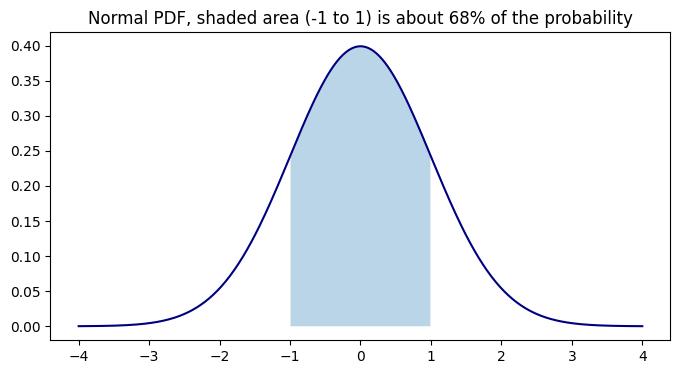

In [11]:
# PDF of a standard normal, with the area from -1 to 1 shaded (about 68%)
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, stats.norm.pdf(x), color='navy')
mask = (x >= -1) & (x <= 1)
plt.fill_between(x[mask], stats.norm.pdf(x[mask]), alpha=0.3)
plt.title("Normal PDF, shaded area (-1 to 1) is about 68% of the probability")
plt.show()

### Normal Distribution
The symmetric bell curve, the most important distribution. Two parameters: mean `mu` (centre) and standard deviation `sigma` (width). Many natural measurements follow it, and sample means become normal by the Central Limit Theorem.

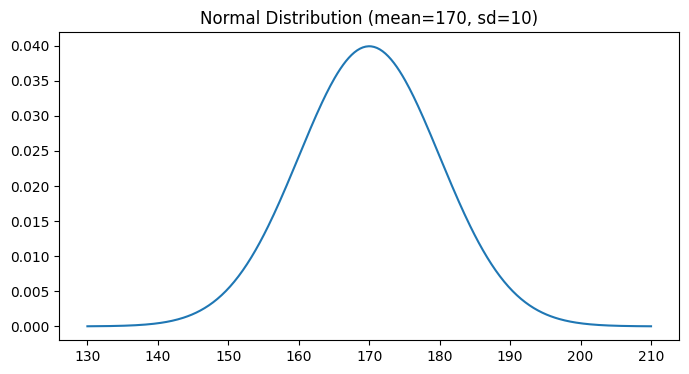

P(height <= 180): 0.8413


In [12]:
# Normal(mean=170, sd=10): heights
x = np.linspace(130, 210, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, stats.norm.pdf(x, 170, 10))
plt.title("Normal Distribution (mean=170, sd=10)")
plt.show()
# P(height <= 180)
print("P(height <= 180):", round(stats.norm.cdf(180, 170, 10), 4))

### Bernoulli Distribution
A single trial with two outcomes, success (1) or failure (0), with success probability `p`. Mean = p, variance = p(1-p). Example: one coin flip.

In [13]:
# one biased coin, P(heads) = 0.3
print("P(success):", stats.bernoulli.pmf(1, 0.3))
print("mean:", stats.bernoulli.mean(0.3), " variance:", round(stats.bernoulli.var(0.3), 2))

P(success): 0.3
mean: 0.3  variance: 0.21


### Binomial Distribution
The number of successes in n independent Bernoulli trials, each with probability `p`. Mean = np, variance = np(1-p). Example: number of heads in 10 coin flips.

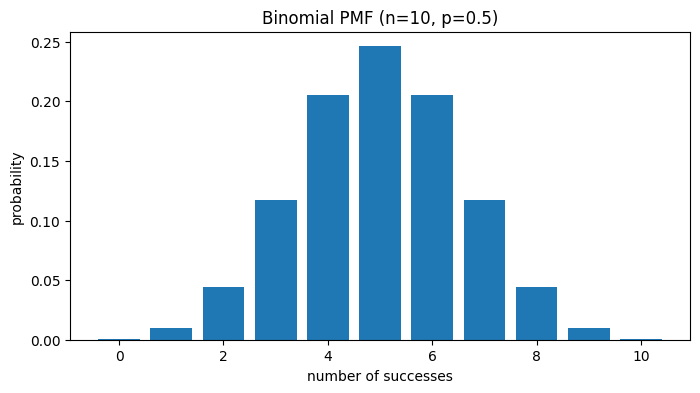

P(exactly 5 heads): 0.2461
mean: 5.0  variance: 2.5


In [14]:
n, p = 10, 0.5
k = np.arange(0, n + 1)
plt.figure(figsize=(8, 4))
plt.bar(k, stats.binom.pmf(k, n, p))
plt.title("Binomial PMF (n=10, p=0.5)")
plt.xlabel("number of successes"); plt.ylabel("probability")
plt.show()
print("P(exactly 5 heads):", round(stats.binom.pmf(5, n, p), 4))
print("mean:", stats.binom.mean(n, p), " variance:", stats.binom.var(n, p))

### Uniform Distribution
Every value is equally likely. Discrete uniform (a fair die) or continuous uniform (any value in a range). Mean = (a+b)/2.

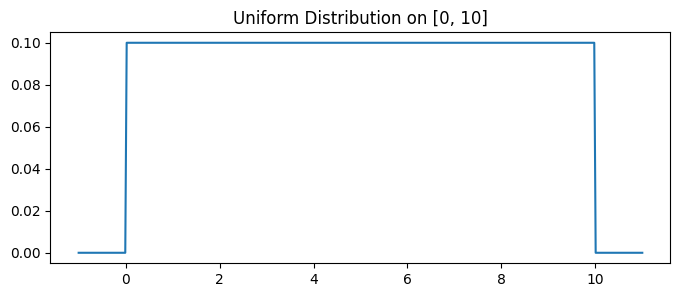

mean: 5.0  variance: 8.33


In [15]:
# continuous uniform on [0, 10]: flat PDF
x = np.linspace(-1, 11, 400)
plt.figure(figsize=(8, 3))
plt.plot(x, stats.uniform.pdf(x, loc=0, scale=10))
plt.title("Uniform Distribution on [0, 10]")
plt.show()
print("mean:", stats.uniform.mean(0, 10), " variance:", round(stats.uniform.var(0, 10), 2))

### Poisson Distribution
The number of rare events in a fixed interval, given an average rate `lambda`. Signature property: mean = variance = lambda. Example: errors per hour on a website (lambda = 3).

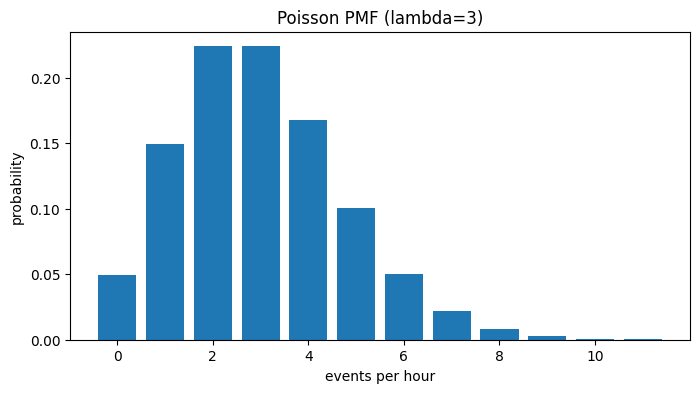

P(exactly 2 errors): 0.224
mean: 3.0  variance: 3.0


In [16]:
lam = 3
k = np.arange(0, 12)
plt.figure(figsize=(8, 4))
plt.bar(k, stats.poisson.pmf(k, lam))
plt.title("Poisson PMF (lambda=3)")
plt.xlabel("events per hour"); plt.ylabel("probability")
plt.show()
print("P(exactly 2 errors):", round(stats.poisson.pmf(2, lam), 4))
print("mean:", stats.poisson.mean(lam), " variance:", stats.poisson.var(lam))

### Standard Normal Distribution
The special normal with mean 0 and standard deviation 1, written Z. Any normal variable converts to it with the z-score, so one curve handles every normal distribution.

### Z-score
The z-score says how many standard deviations a value is from the mean:

`z = (x - mean) / standard deviation`

Positive z is above the mean, negative is below. It also puts values from different scales on one common scale (standardization), a very common machine learning preprocessing step.

In [17]:
# x = 130 from Normal(mean=100, sd=15)
x, mu, sigma = 130, 100, 15
z = (x - mu) / sigma
print("z-score:", z)                                  # 2.0
print("P(X <= 130) via original :", round(stats.norm.cdf(130, mu, sigma), 4))
print("P(Z <= 2.0) via standard :", round(stats.norm.cdf(z), 4))   # same value

z-score: 2.0
P(X <= 130) via original : 0.9772
P(Z <= 2.0) via standard : 0.9772


### Empirical Rule (68-95-99.7)
For a normal distribution, fixed percentages fall within whole standard deviations of the mean:

- about 68% within 1 SD
- about 95% within 2 SD
- about 99.7% within 3 SD

A value beyond 3 SDs (z > 3) is rarer than 0.3%, a common definition of an outlier.

In [18]:
for ksd in (1, 2, 3):
    p = stats.norm.cdf(ksd) - stats.norm.cdf(-ksd)
    print(f"within {ksd} SD: {round(p*100, 1)}%")

within 1 SD: 68.3%
within 2 SD: 95.4%
within 3 SD: 99.7%


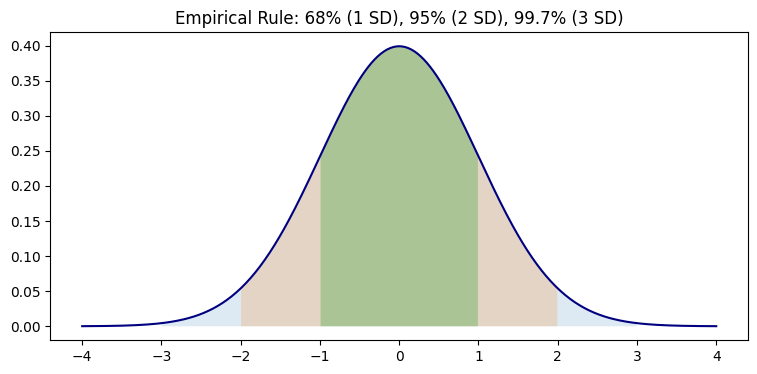

In [19]:
# visualize the empirical rule
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(9, 4))
plt.plot(x, stats.norm.pdf(x), color='navy')
for ksd, alpha in [(3, 0.15), (2, 0.2), (1, 0.3)]:
    m = (x >= -ksd) & (x <= ksd)
    plt.fill_between(x[m], stats.norm.pdf(x[m]), alpha=alpha)
plt.title("Empirical Rule: 68% (1 SD), 95% (2 SD), 99.7% (3 SD)")
plt.show()

### Recap
- statistics has two branches: descriptive (summarize) and inferential (generalize from a sample)
- data is categorical (labels) or numerical (discrete or continuous)
- levels: nominal, ordinal (qualitative), interval, ratio (quantitative)
- centre: mode, median, mean. spread: range, variance, standard deviation
- skewness measures asymmetry (left, symmetric, right)
- PDF gives probability as area under a curve
- key distributions: normal, Bernoulli, binomial, uniform, Poisson
- standard normal (Z) plus the z-score and empirical rule standardize and interpret normal data